In [2]:
import sys
print(sys.version)
print(sys.executable)

3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
c:\Users\shyam\anaconda3\python.exe


In [1]:
import shap
print(shap.__version__)

0.52.0


In [2]:
import pandas as pd
import shap
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

In [2]:
import numpy as np
import shap

print(np.__version__)
print(shap.__version__)

1.26.4
0.46.0


In [3]:
import pandas as pd
import shap
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv(
    r"C:\Users\shyam\OneDrive\Documents\customer-churn-ltv-engine\data\raw\telco_churn.csv"
)

print(df.shape)

(7043, 33)


In [5]:
# Remove unwanted columns

df = df.drop([
    'CustomerID',
    'Country',
    'State',
    'City',
    'Lat Long',
    'Churn Reason'
], axis=1)

print(df.shape)

(7043, 27)


In [6]:
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

df['Total Charges'] = df['Total Charges'].fillna(
    df['Total Charges'].median()
)

print(df['Total Charges'].isnull().sum())

0


In [7]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.shape)

(7043, 38)


In [8]:
X = df_encoded.drop([
    'Churn Value',
    'Churn Label_Yes',
    'Churn Score',
    'CLTV'
], axis=1)

y = df_encoded['Churn Value']

print(X.shape)
print(y.shape)

(7043, 34)
(7043,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5634, 34)
(1409, 34)


In [11]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [13]:
print(type(xgb_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [14]:
import xgboost
print(xgboost.__version__)

3.2.0


In [16]:
print(type(xgb_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [18]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                            Feature  Importance
14     Internet Service_Fiber optic    0.314463
29                Contract_Two year    0.232560
28                Contract_One year    0.087185
15              Internet Service_No    0.077565
10                   Dependents_Yes    0.054572
4                     Tenure Months    0.026281
27             Streaming Movies_Yes    0.020983
32  Payment Method_Electronic check    0.014762
11                Phone Service_Yes    0.014216
23                 Tech Support_Yes    0.013436


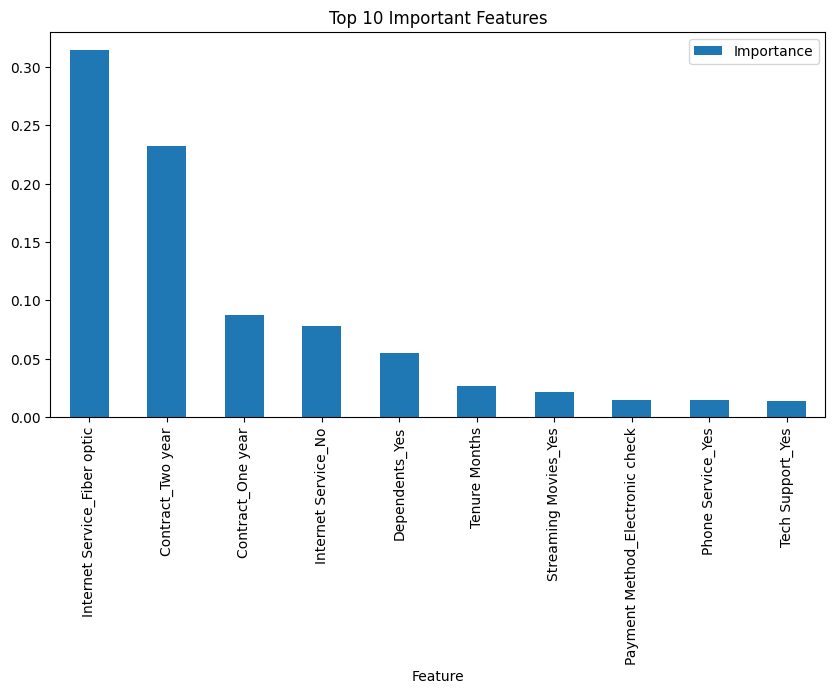

In [19]:
import matplotlib.pyplot as plt

importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Important Features")
plt.show()

## Business Insights

1. Customers using Fiber Optic Internet are more likely to churn.
2. Customers with One-Year and Two-Year contracts are less likely to churn.
3. Customers without dependents show higher churn behavior.
4. Tenure is an important factor; long-term customers are more likely to stay.
5. Customers using Electronic Check payment methods have higher churn risk.
6. Customers with Tech Support subscriptions are more likely to remain loyal.